# Airlines Delay Data

## Data Acquisition and Pre-Processing

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification


In [2]:
df = pd.read_csv("datasets/airlines_delay.csv", sep=",")
df.info()
# label encode categorical variables
AirlineUnique = df.Airline.unique()
AirportFromUnique = df.AirportFrom.unique()
AirportToUnique = df.AirportTo.unique()

Airlinelst = list(range(len(AirlineUnique)))
df['NumAirline'] = df['Airline']
df['NumAirline'].replace(AirlineUnique, Airlinelst, inplace=True)

AirportFromlst = list(range(len(AirportFromUnique)))
df['NumAirportFrom'] = df['AirportFrom']
df['NumAirportFrom'].replace(AirportFromUnique, AirportFromlst, inplace=True)

AirportTolst = list(range(len(AirportToUnique)))
df['NumAirportTo'] = df['AirportTo']
df['NumAirportTo'].replace(AirportToUnique, AirportTolst, inplace=True)

# reduce dataset size
df = df.sample(n=10000)

X = df[['Length','NumAirline','NumAirportFrom','NumAirportTo','DayOfWeek']]
y = df['Class']


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 539382 entries, 0 to 539381
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Flight       539382 non-null  float64
 1   Time         539382 non-null  float64
 2   Length       539382 non-null  float64
 3   Airline      539382 non-null  object 
 4   AirportFrom  539382 non-null  object 
 5   AirportTo    539382 non-null  object 
 6   DayOfWeek    539382 non-null  int64  
 7   Class        539382 non-null  int64  
dtypes: float64(3), int64(2), object(3)
memory usage: 32.9+ MB


/var/folders/61/4f_9vd3x7c9_5dsr15qd4fww0000gn/T/ipykernel_36751/3482191850.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['NumAirline'].replace(AirlineUnique, Airlinelst, inplace=True)
/var/folders/61/4f_9vd3x7c9_5dsr15qd4fww0000gn/T/ipykernel_36751/3482191850.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent

## Create Simulated Datasets

In [3]:
X_simulated_small, y_simulated_small = make_classification(
    n_samples=300,
    n_features=6,
    n_classes=2,
    random_state=1
)

X_simulated_large, y_simulated_large = make_classification(
    n_samples=15000,
    n_features=6,
    n_classes=2,
    random_state=1
)

## Exploratory Data Analysis

In [4]:
flights_per_airline = df.groupby('Airline').agg({'Class':'count'})
delays_by_airline = df.groupby('Airline').agg({'Class':'sum'})
flights_per_airline['%_delays'] = 100*delays_by_airline['Class']/flights_per_airline['Class']


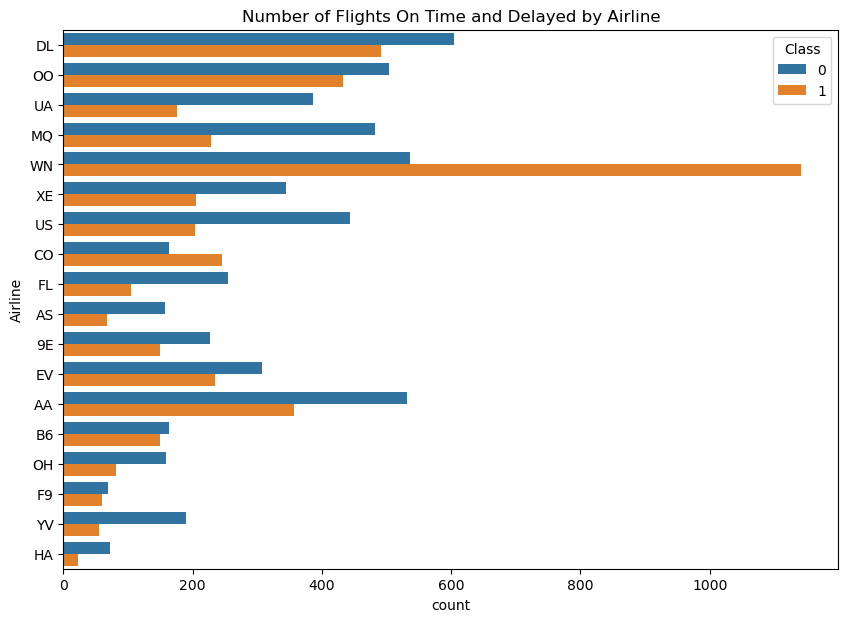

In [5]:
plt.figure(figsize=(10,7))
sns.countplot(y='Airline', hue='Class', data=df)
plt.title('Number of Flights On Time and Delayed by Airline')
plt.show()


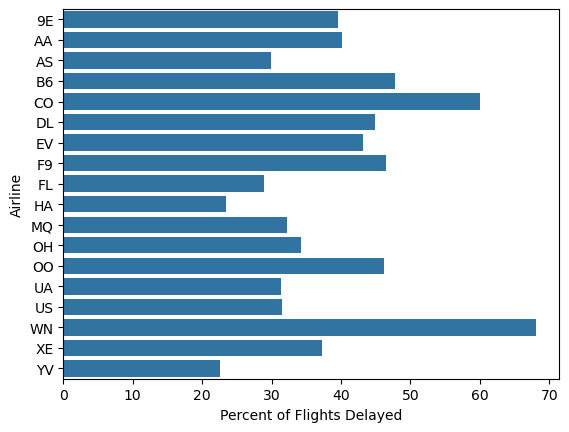

In [6]:
sns.barplot(y='Airline', x='%_delays', data=flights_per_airline, orient='h', color='C0')
plt.xlabel('Percent of Flights Delayed')
plt.ylabel('Airline')
plt.show()


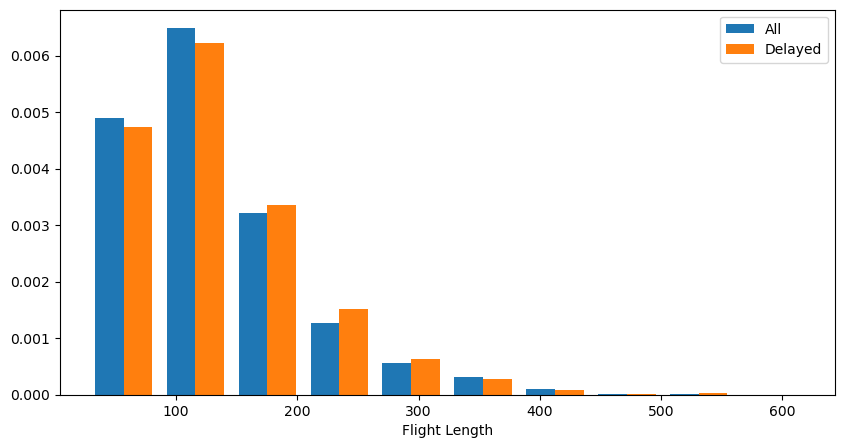

In [7]:
delayed = df[df['Class']==1]
plt.figure(figsize=(10,5))
plt.hist([df['Length'], delayed['Length']], label=['All','Delayed'], density=True)
plt.legend()
plt.xlabel('Flight Length')
plt.show()


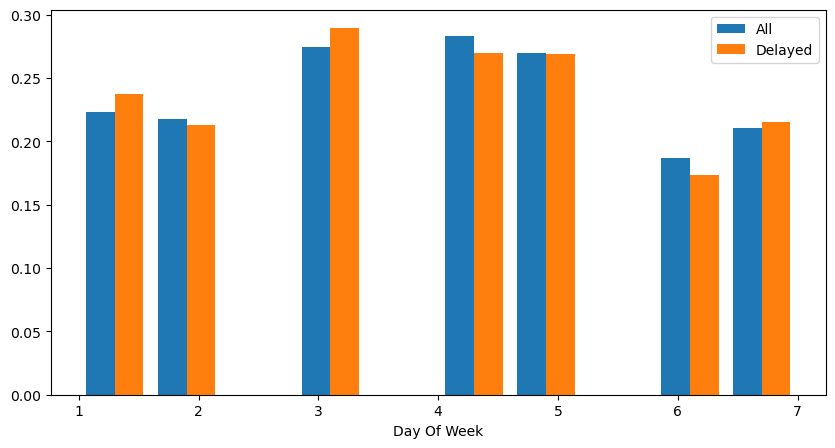

In [8]:
plt.figure(figsize=(10,5))
plt.hist([df['DayOfWeek'], delayed['DayOfWeek']], label=['All','Delayed'], density=True)
plt.legend()
plt.xlabel('Day Of Week')
plt.show()


/var/folders/61/4f_9vd3x7c9_5dsr15qd4fww0000gn/T/ipykernel_36751/10489645.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  delays['TimeBin'] = pd.cut(delays['Time'], bins=time_bins, include_lowest=True, right=False)
/var/folders/61/4f_9vd3x7c9_5dsr15qd4fww0000gn/T/ipykernel_36751/10489645.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = delays.groupby(['DayOfWeek','TimeBin']).size().unstack(fill_value=0)


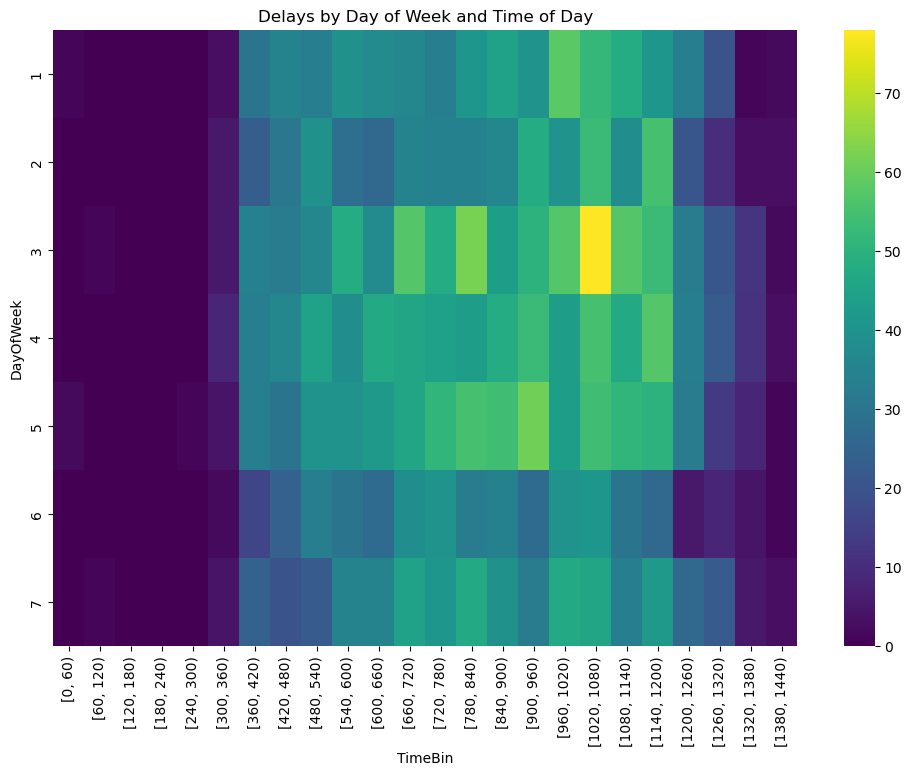

In [9]:
time_bins = [0]
initial_time = 0
for i in range(24):
    initial_time += 60
    time_bins.append(initial_time)

df['TimeBin'] = pd.cut(df['Time'], bins=time_bins, include_lowest=True, right=False)
delays = df[df['Class']==1]
delays['TimeBin'] = pd.cut(delays['Time'], bins=time_bins, include_lowest=True, right=False)
counts = delays.groupby(['DayOfWeek','TimeBin']).size().unstack(fill_value=0)
plt.figure(figsize=(12,8))
sns.heatmap(counts, cmap='viridis')
plt.title('Delays by Day of Week and Time of Day')
plt.show()
